In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv(r"Untitled spreadsheet - Sheet1.csv")
df.head(5)

,Day,outlook,humidity,windy,play
0,2,sunny,hot,false,no
1,3,overcast,hot,true,yes
2,1,sunny,hot,false,no
3,4,rainy,mild,false,yes
4,5,rainy,cool,false,yes


In [3]:
df.shape


(14, 5)

In [4]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df = df.apply(le.fit_transform)
df.head(5)

,Day,outlook,humidity,windy,play
0,1,2,1,0,0
1,2,0,1,3,1
2,0,2,1,0,0
3,3,1,2,0,1
4,4,1,0,0,1


In [5]:
X = df.drop(['play'],axis = 1)
X.head(4)

,Day,outlook,humidity,windy
0,1,2,1,0
1,2,0,1,3
2,0,2,1,0
3,3,1,2,0


In [6]:
y = df.play
y.head(5)

0    0
1    1
2    0
3    1
4    1
Name: play, dtype: int64

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size =0.30)


In [21]:
from sklearn.tree import DecisionTreeClassifier
classifire = DecisionTreeClassifier(criterion='entropy')
classifire.fit(X_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [22]:
y_pred = classifire.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.6

In [24]:
import matplotlib.pyplot as plt
from sklearn import tree


[Text(0.5, 0.9, 'x[0] <= 1.5\nentropy = 0.98\nsamples = 12\nvalue = [5, 7]'),
 Text(0.3333333333333333, 0.7, 'entropy = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.41666666666666663, 0.8, 'True  '),
 Text(0.6666666666666666, 0.7, 'x[0] <= 12.5\nentropy = 0.881\nsamples = 10\nvalue = [3, 7]'),
 Text(0.5833333333333333, 0.8, '  False'),
 Text(0.5, 0.5, 'x[0] <= 7.5\nentropy = 0.764\nsamples = 9\nvalue = [2, 7]'),
 Text(0.3333333333333333, 0.3, 'x[0] <= 4.5\nentropy = 0.971\nsamples = 5\nvalue = [2, 3]'),
 Text(0.16666666666666666, 0.1, 'entropy = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.5, 0.1, 'entropy = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.6666666666666666, 0.3, 'entropy = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.8333333333333334, 0.5, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]')]

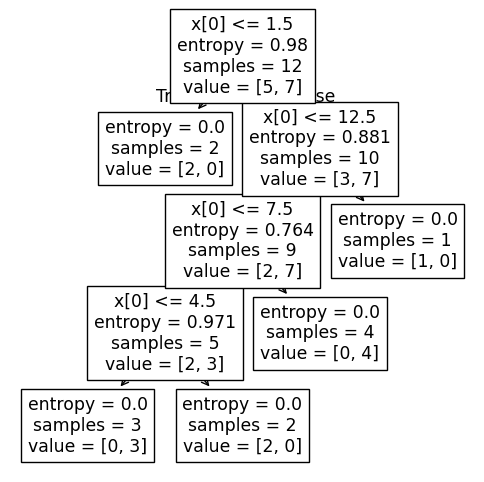

In [19]:
fig, axes = plt.subplots(nrows = 1,ncols= 1,figsize = (6,6),dpi = 100)
tree.plot_tree(classifire)